In [1]:
import os
# import gc
import asyncio
from typing import Type

from connector.monitor import Monitor
from connector.connector import BaseConnector
from connector.binance.binance_perp import BinancePerp
from connector.binance.binance_spot import BinanceSpot

print(f"PID: {os.getpid()}")
connector_type_list: list[Type[BaseConnector]] = [BinancePerp, BinanceSpot]
m = Monitor(connector_type_list=connector_type_list)
#gc.disable()
task = asyncio.create_task(m.run())


PID: 3190710


In [56]:
task.cancel()  # отправляем CancelledError в run()
await task 

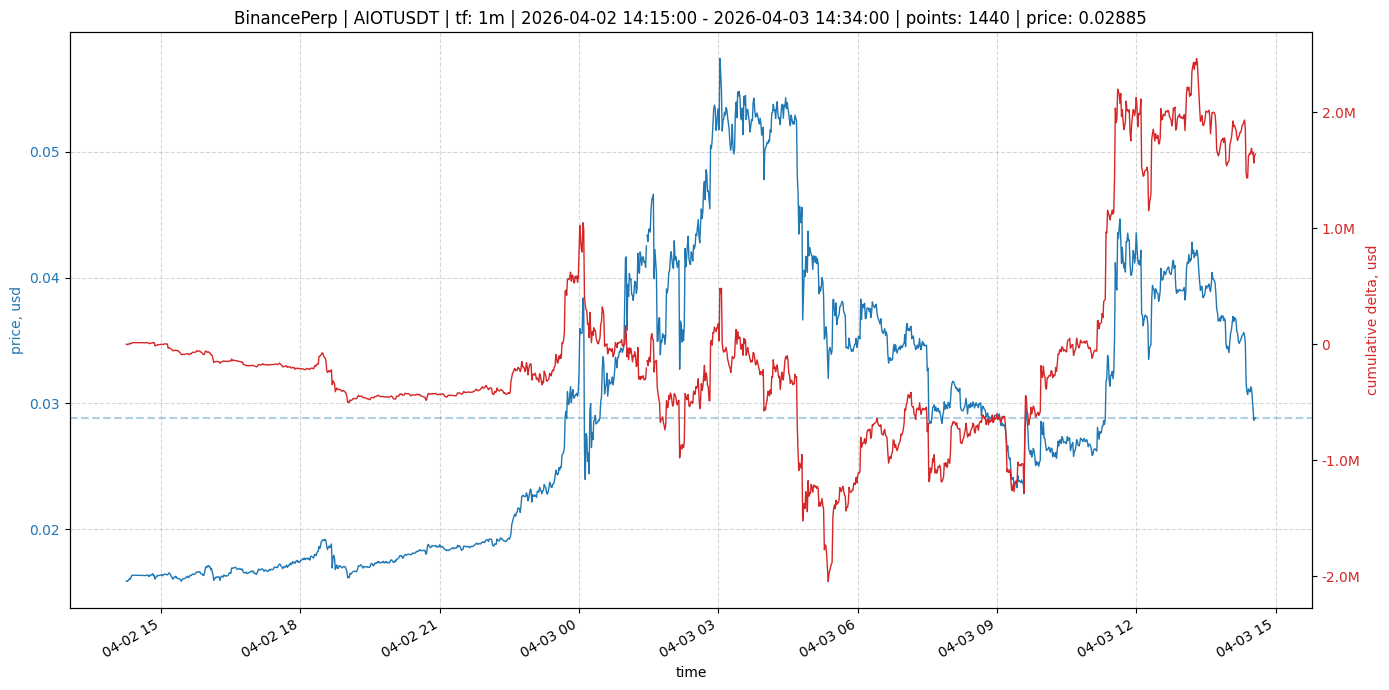

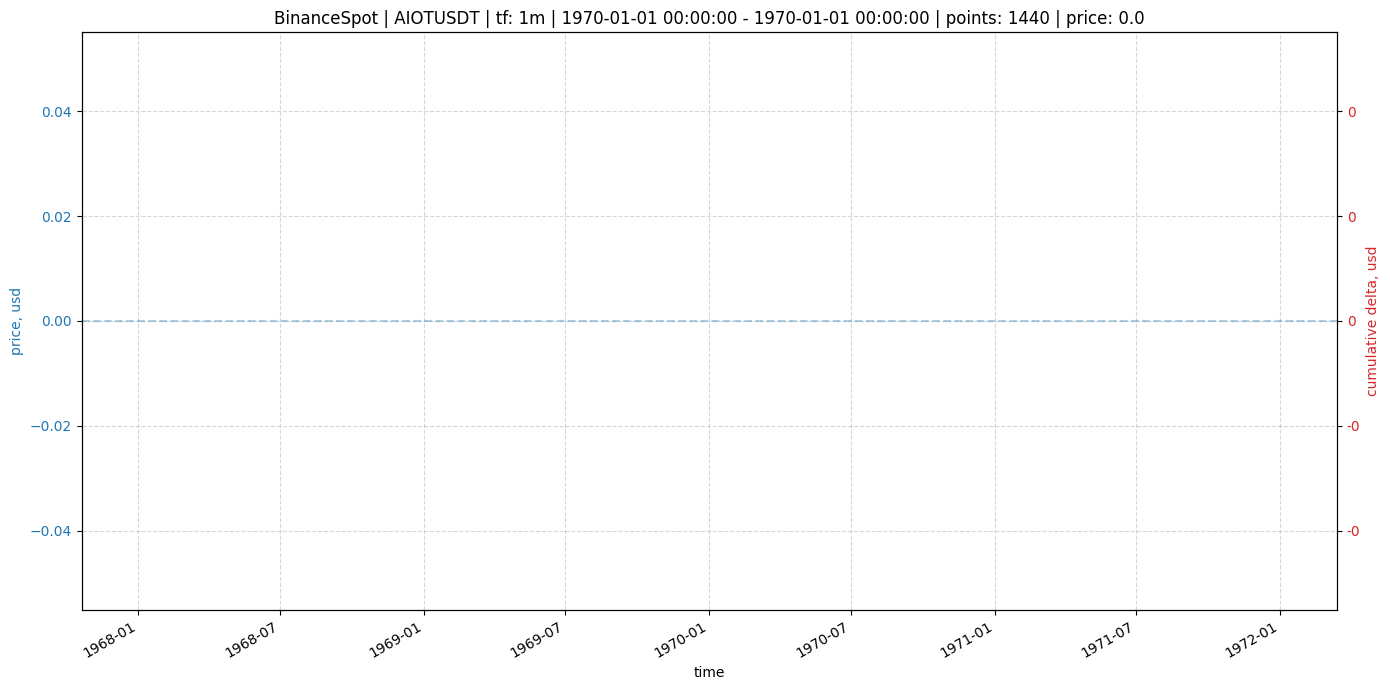

In [2]:
import importlib
import connector.visualization as visual
importlib.reload(visual)

symbol = "AIOTUSDT"
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1m")
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinanceSpot], "1m")

In [ ]:
import importlib
import connector.utils_io as utils_io
importlib.reload(utils_io)

await utils_io.save_all_trade_data(m.connectors)

In [45]:
import pandas as pd
rows = []
for symbol, trade_container in m.connectors[BinancePerp].trade_service.containers.items():
    idx = trade_container.public_trades_1m.idx
    size = trade_container.public_trades_1m.size
    i = idx % size
    price_close = trade_container.public_trades_1m.prices[i]
    price_open = trade_container.public_trades_1m.prices[0 if idx < size else (idx + 1) % size]
    rows.append({"symbol": symbol, "price_open": price_open, "price_close": price_close, "delta": round((price_close/price_open-1)*100, 1)})

df = pd.DataFrame(rows)
df.sort_values("delta", ascending=False)


,symbol,price_open,price_close,delta
33,AIOTUSDT,0.014500,0.026700,84.1
89,CTSIUSDT,0.024100,0.037700,56.4
179,YBUSDT,0.099900,0.144600,44.7
313,ONGUSDT,0.068430,0.095260,39.2
108,EDGEUSDT,0.693800,0.902400,30.1
...,...,...,...,...
374,SWARMSUSDT,0.010988,0.008281,-24.6
287,ONUSDT,0.114710,0.078640,-31.4
340,BANKUSDT,0.042590,0.029110,-31.7
123,NOMUSDT,0.010338,0.006509,-37.0


In [52]:
pt = m.connectors[BinancePerp].trade_service["AIOTUSDT"].public_trades
prices = pt.prices[:(pt.idx + 1) % pt.size]
vols = pt.volumes[:(pt.idx + 1) % pt.size]
rows = []
for price, qty in zip(prices, vols):
    rows.append({"price": price, "qty": qty})
df = pd.DataFrame(rows)
df.head(20)

,price,qty
0,0.02684,-4101.0
1,0.02683,-826.0
2,0.02684,-208.0
3,0.02683,-449.0
4,0.02682,-13639.0
5,0.02681,-26030.0
6,0.02680,-2128.0
7,0.02684,-208.0
8,0.02683,-208.0
9,0.02682,659.0


In [34]:
m.connectors[BinanceSpot].instrument_manager["BTCUSDT"]

Instrument(exchange_symbol='BTCUSDT', unified_symbol='BTCUSDT', min_price=None, max_price=None, price_step=None, min_qty=None, max_qty=None, qty_step=None)

In [11]:
m.connectors[BinancePerp].trade_service.containers.items()

dict_items([('APTUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3c4183950>), ('1000CATUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3c43e6dd0>), ('SOPHUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3c415cfd0>), ('SAGAUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3c4183750>), ('0GUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3c4183a90>), ('DOLOUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3c4180d90>), ('GIGGLEUSDT', <connector.public_trade_service.TradesContainer object at 0x77e393669110>), ('HUMAUSDT', <connector.public_trade_service.TradesContainer object at 0x77e393669150>), ('TIAUSDT', <connector.public_trade_service.TradesContainer object at 0x77e393669190>), ('SAHARAUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3936691d0>), ('LAYERUSDT', <connector.public_trade_service.TradesContainer object at 0x77e393669210>), ('DEN

In [ ]:
perp_symbols = set(instrument.unified_symbol for instrument in m.connectors[BinancePerp].instrument_manager.values())
spot_symbols = set(instrument.unified_symbol for instrument in m.connectors[BinanceSpot].instrument_manager.values())
unified_symbols = perp_symbols & spot_symbols
len(perp_symbols), len(spot_symbols), len(unified_symbols)

(542, 439, 371)

In [ ]:
m.connectors[BinancePerp].orderbook_service["BTCUSDT"].message

''

In [ ]:
m.connectors[BinanceSpot].orderbook_service["BTCUSDT"].message

'{"u":91193085088,"s":"BTCUSDT","b":"67026.03000000","B":"2.42203000","a":"67026.04000000","A":"0.24394000"}'

In [ ]:
m.connectors[BinanceSpot].trade_service["BTCUSDT"].public_trades

68300.37

In [ ]:
m.connectors[BinanceSpot].trade_service["BTCUSDT"].public_trades_1s

In [4]:
min_delay = 0

In [ ]:
exchange_symbol = "BTCUSDT"
perp_ask_price: float = m.connectors[BinancePerp].orderbook_service[exchange_symbol].best_ask
perp_bid_price: float = m.connectors[BinancePerp].orderbook_service[exchange_symbol].best_bid
spot_bid_price: float = m.connectors[BinanceSpot].orderbook_service[exchange_symbol].best_bid
spot_ask_price: float = m.connectors[BinanceSpot].orderbook_service[exchange_symbol].best_ask
delay = int(time.time()*1000 - m.connectors[BinanceSpot].orderbook_service[exchange_symbol].transaction_ts_ms)
delay2 = int(time.time()*1000 - m.connectors[BinancePerp].trade_service[exchange_symbol][-1].transaction_ts_ms)
if min_delay>delay:
    min_delay=delay
perp_ask_price, perp_bid_price, spot_bid_price, spot_ask_price, delay-min_delay, delay2-min_delay, min_delay

(0, 0, 0, 0, 76, 65, -1063)

In [ ]:
m.connectors[BinancePerp].orderbook_service.text_data.qsize()

0